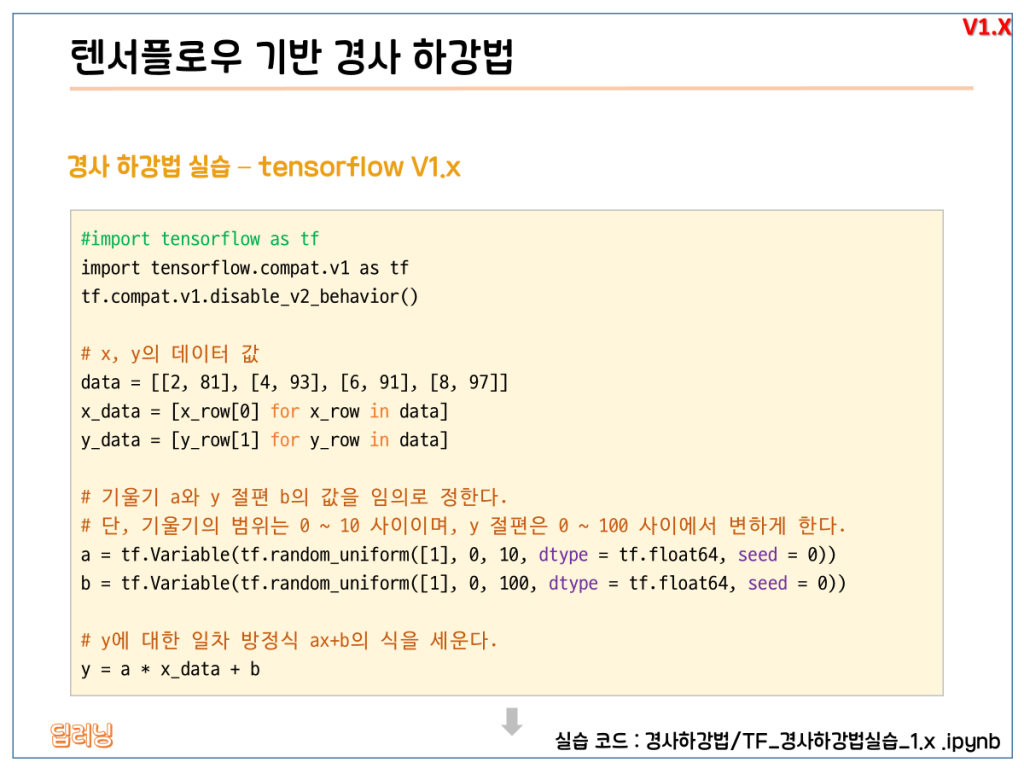

In [9]:
import tensorflow.compat.v1 as tf
tf.compat.v1.disable_v2_behavior()

data = [[2,81],[4,93],[6,91],[8,97]]
x_data = [x_row[0] for x_row in data]
y_data = [y_row[1] for y_row in data] # 실제 y 값

a = tf.Variable(tf.random_uniform([1], 0, 10, dtype = tf.float64, seed = 0)) # 균등분포, 값 1개 추출? 0~10 사이(이건 관례적으로 임의로 정한 숫자) <- TensorFlow 사용하므로 tf 자료형 필요(tf.Variable(o))
b = tf.Variable(tf.random_uniform([1], 0, 100, dtype = tf.float64, seed = 0))
# seed 0 = ai 모델링의 재현성을 위해? seed 값이 같으면 같은 random 값이 나옴

y = a * x_data + b # 예측 y 값

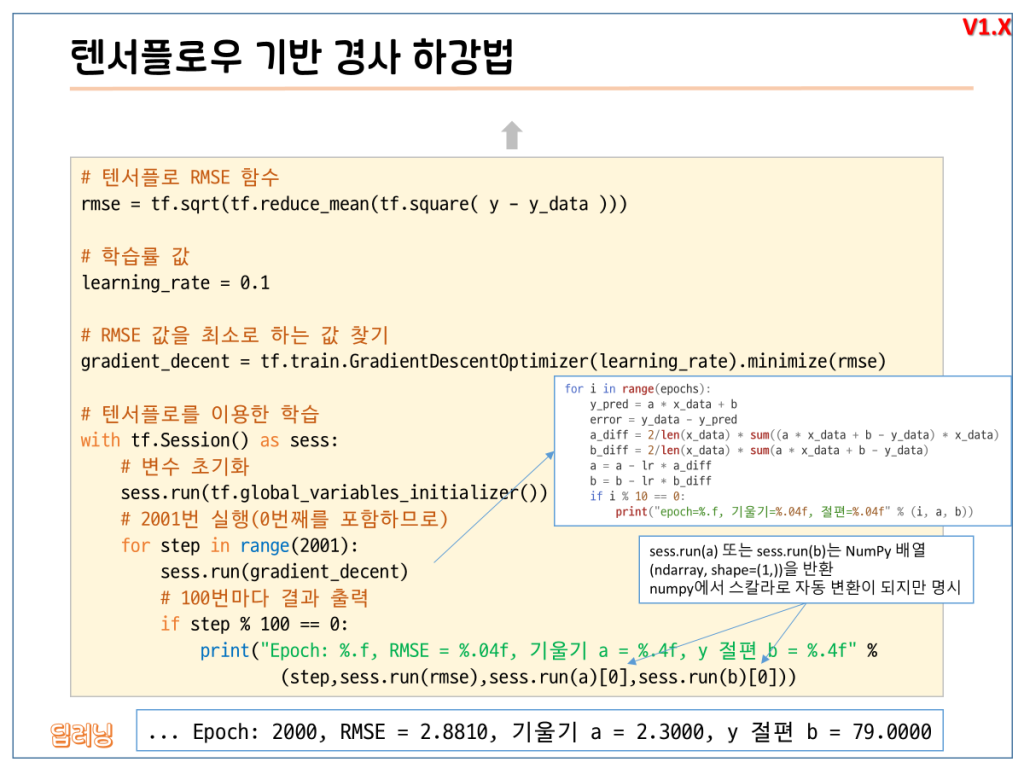

In [3]:
rmse = tf.sqrt(tf.reduce_mean(tf.square(y - y_data))) # 에러 수식

learning_rate = 0.1 # 어느 정도 보폭으로 움직일지 hyper parameter(모델링 돌리면서 감각적으로 조정해야 함, 0.01 ~ 0.001 등, ADAM에서는 모델이 스스로 learning rate를 조정함)

# tf의 학습 알고리즘 중 경사하강법
gradient_decent = tf.train.GradientDescentOptimizer(learning_rate).minimize(rmse)

# tf v1에서는 세션 안에서만 동작함, 세션 안이 아니면 개발자가 모니터링 불가능
with tf.Session() as sess:
    sess.run(tf.global_variables_initializer()) # 변수에 값 할당

    for step in range(2001):
        sess.run(gradient_decent)
        if step % 100 == 0:
            print("Epoch: %.f, RMSE = %.04f, 기울기 a = %.4f, y절편 b = %.4f" %(step, sess.run(rmse), sess.run(a)[0], sess.run(b)[0]))

2026-09-21 19:52:17.751830: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled


Epoch: 0, RMSE = 30.2139, 기울기 a = 7.5235, y절편 b = 80.5984
Epoch: 100, RMSE = 2.8860, 기울기 a = 2.2299, y절편 b = 79.4181
Epoch: 200, RMSE = 2.8826, 기울기 a = 2.2601, y절편 b = 79.2379
Epoch: 300, RMSE = 2.8815, 기울기 a = 2.2773, y절편 b = 79.1353
Epoch: 400, RMSE = 2.8811, 기울기 a = 2.2871, y절편 b = 79.0770
Epoch: 500, RMSE = 2.8810, 기울기 a = 2.2927, y절편 b = 79.0438
Epoch: 600, RMSE = 2.8810, 기울기 a = 2.2958, y절편 b = 79.0249
Epoch: 700, RMSE = 2.8810, 기울기 a = 2.2976, y절편 b = 79.0142
Epoch: 800, RMSE = 2.8810, 기울기 a = 2.2987, y절편 b = 79.0081
Epoch: 900, RMSE = 2.8810, 기울기 a = 2.2992, y절편 b = 79.0046
Epoch: 1000, RMSE = 2.8810, 기울기 a = 2.2996, y절편 b = 79.0026
Epoch: 1100, RMSE = 2.8810, 기울기 a = 2.2998, y절편 b = 79.0015
Epoch: 1200, RMSE = 2.8810, 기울기 a = 2.2999, y절편 b = 79.0008
Epoch: 1300, RMSE = 2.8810, 기울기 a = 2.2999, y절편 b = 79.0005
Epoch: 1400, RMSE = 2.8810, 기울기 a = 2.3000, y절편 b = 79.0003
Epoch: 1500, RMSE = 2.8810, 기울기 a = 2.3000, y절편 b = 79.0002
Epoch: 1600, RMSE = 2.8810, 기울기 a = 2.3000, y절편 b =

In [8]:
mse = tf.reduce_mean(tf.square(y - y_data)) # 에러 수식

learning_rate = 0.01 # 어느 정도 보폭으로 움직일지 hyper parameter(모델링 돌리면서 감각적으로 조정해야 함, 0.01 ~ 0.001 등, ADAM에서는 모델이 스스로 learning rate를 조정함)

# tf의 학습 알고리즘 중 경사하강법
gradient_decent2 = tf.train.GradientDescentOptimizer(learning_rate).minimize(mse)

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer()) 

    for step in range(2001):
        sess.run(gradient_decent2)
        if step % 100 == 0:
            print("Epoch: %.f, MSE = %.04f, 기울기 a = %.4f, y절편 b = %.4f" %(step, sess.run(mse), sess.run(a)[0], sess.run(b)[0]))

Epoch: 0, MSE = 169.7570, 기울기 a = 4.4386, y절편 b = 80.0794
Epoch: 100, MSE = 8.3428, 기울기 a = 2.2151, y절편 b = 79.5069
Epoch: 200, MSE = 8.3224, 기울기 a = 2.2386, y절편 b = 79.3663
Epoch: 300, MSE = 8.3117, 기울기 a = 2.2556, y절편 b = 79.2647
Epoch: 400, MSE = 8.3061, 기울기 a = 2.2679, y절편 b = 79.1913
Epoch: 500, MSE = 8.3032, 기울기 a = 2.2768, y절편 b = 79.1382
Epoch: 600, MSE = 8.3017, 기울기 a = 2.2833, y절편 b = 79.0999
Epoch: 700, MSE = 8.3009, 기울기 a = 2.2879, y절편 b = 79.0722
Epoch: 800, MSE = 8.3005, 기울기 a = 2.2913, y절편 b = 79.0522
Epoch: 900, MSE = 8.3002, 기울기 a = 2.2937, y절편 b = 79.0377
Epoch: 1000, MSE = 8.3001, 기울기 a = 2.2954, y절편 b = 79.0272
Epoch: 1100, MSE = 8.3001, 기울기 a = 2.2967, y절편 b = 79.0197
Epoch: 1200, MSE = 8.3000, 기울기 a = 2.2976, y절편 b = 79.0142
Epoch: 1300, MSE = 8.3000, 기울기 a = 2.2983, y절편 b = 79.0103
Epoch: 1400, MSE = 8.3000, 기울기 a = 2.2988, y절편 b = 79.0074
Epoch: 1500, MSE = 8.3000, 기울기 a = 2.2991, y절편 b = 79.0054
Epoch: 1600, MSE = 8.3000, 기울기 a = 2.2993, y절편 b = 79.0039
Epoch: 